In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"]
)

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
print(df.shape)
print("VALUE COUNTS ", df["label"].value_counts())
print('NULLS ', df.isnull().sum())

(5572, 2)
VALUE COUNTS  label
ham     4825
spam     747
Name: count, dtype: int64
NULLS  label    0
text     0
dtype: int64


In [3]:
df["length"] = df["text"].apply(len)
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


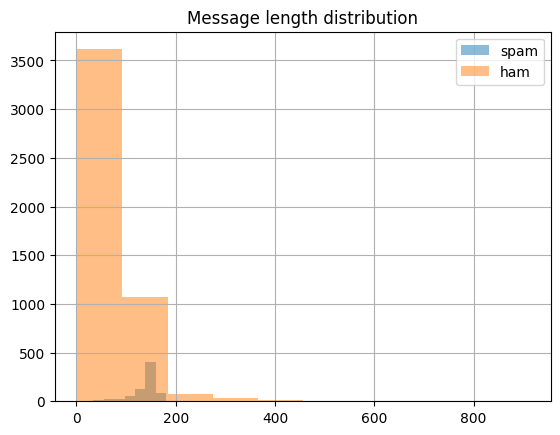

In [4]:
import matplotlib.pyplot as plt

df[df["label"] == "spam"]["length"].hist(alpha=0.5)
df[df["label"] == "ham"]["length"].hist(alpha=0.5)
plt.legend(["spam", "ham"])
plt.title("Message length distribution")
plt.show()

Самые частые слова

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [6]:
from collections import Counter

spam_words = " ".join(df[df["label"]=="spam"]["clean_text"]).split()
Counter(spam_words).most_common(20)

[('to', 689),
 ('a', 380),
 ('call', 350),
 ('you', 287),
 ('your', 263),
 ('free', 219),
 ('for', 204),
 ('the', 204),
 ('now', 190),
 ('or', 188),
 ('is', 158),
 ('u', 155),
 ('txt', 151),
 ('on', 145),
 ('ur', 144),
 ('have', 135),
 ('from', 129),
 ('mobile', 124),
 ('and', 122),
 ('text', 121)]

Dataset contains 5572 messages

Spam percentage is 13.4%

Spam messages tend to be longer

Most common spam words are 'to', 'a', 'call', 'you', 'your', 'free', 'for', 'the', 'now', 'or', 'is', 'u', 'txt', on, ur, have, from, mobile, and, text